# Guided molecular generation with MolMIM

```{note}
This notebook assumes that you have the MolMIM NIM available at the following address: `http://localhost:$CONTAINER_PORT`. If your container is available at different address, you will need to modify the URL below. If you haven't already, Please follow the steps in container_setup.ipynb
```

This tutorial demonstrates how to use the molmim_cma package to optimize exploration of the [MolMIM](https://arxiv.org/abs/2208.09016) model's latent space to generate molecules
with properties of interest. To do this, we use the [CMA-ES](https://en.wikipedia.org/wiki/CMA-ES) genetic optimization algorithm. The basic steps of optimization are:

1. Decode latent representations into smiles strings
2. Score generated smiles strings based on the desired oracle function
3. Update the CMA-ES algorithm with the smiles/score pairing
4. Ask the CMA-ES algorithm for a new set of latent space representations to sample.


Then we can import and install library dependencies.

In [ ]:
import asyncio
import os
import time
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, QED, rdFingerprintGenerator, FilterCatalog
from rdkit.Chem.FilterCatalog import FilterCatalogParams

from guided_molecule_gen.optimizer import MoleculeGenerationOptimizer
from guided_molecule_gen.oracles import tanimoto_similarity

import pickle

try:
    from boltz2_client import Boltz2Client, Polymer, Ligand, PredictionRequest, PocketConstraint
    BOLTZ2_AVAILABLE = True
except ImportError:
    Boltz2Client = None
    Polymer = None
    Ligand = None
    PredictionRequest = None
    PocketConstraint = None
    BOLTZ2_AVAILABLE = False

### Composite Scoring Aligned With Challenge Evaluation

The hackathon evaluator (`scoring/evaluate_submission.py`) builds a weighted composite using:
- On-target potency against CDK4/6
- Selectivity and CDK11 avoidance
- QED and synthetic accessibility
- PAINS penalties
- Novelty versus ChEMBL

We'll mirror those terms (with deterministic fallbacks when Boltz2 affinity predictions are unavailable) and feed the resulting weighted score into CMA-ES.

In [ ]:
EVALUATION_WEIGHTS: Dict[str, float] = {
    "binding_affinity": 0.25,
    "selectivity": 0.15,
    "cdk11_avoidance": 0.20,
    "qed": 0.15,
    "sa": 0.10,
    "pains": 0.10,
    "novelty": 0.05,
}
NOVELTY_CUTOFF: float = 0.85

CDK_PROTEIN_INFO: Dict[str, Dict[str, Any]] = {
    "CDK4": {
        "sequence": (
            "MATSRYEPVAEIGVGAYGTVYKARDPHSGHFVALKSVRVPNGGGGGGGLPISTVREVALLRRLEAF"
            "EHPNVVRLMDVCATSRTDREIKVTLVFEHVDQDLRTYLDKAPPPGLPAETIKDLMRQFLRGLDFLH"
            "ANCIVHRDLKPENILVTSGGTVKLADFGLARIYSYQMALTPVVVTLWYRAPEVLLQSTYATPVDMW"
            "SVGCIFAEMFRRKPLFCGNSEADQLGKIFDLIGLPPEDDWPRDVSLPRGAFPPRGPRPVQSVVPEM"
            "EESGAQLLLEMLTFNPHKRISAFRALQHSYLHKDEGNPE"
        ),
        "binding_site_residues": [
            {"residue": "Lys35", "position": 35},
            {"residue": "Glu71", "position": 71},
            {"residue": "Val96", "position": 96},
            {"residue": "Lys112", "position": 112},
            {"residue": "Asp158", "position": 158},
            {"residue": "Phe164", "position": 164},
            {"residue": "Leu196", "position": 196},
        ],
    },
        "sequence": (
            "ALQGCRSVEEFQCLNRIEEGTYGVVYRAKDKKTDEIVALKRLKMEKEKEGFPITSLREINTILKAQ"
            "HPNIVTVREIVVGSNMDKIYIVMNYVEHDLKSLMETMKQPFLPGEVKTLMIQLLRGVKHLHDNWIL"
            "HRDLKTSNLLLSHAGILKVGDFGLAREYGSPLKAYTPVVVTLWYRAPELLLGAKEYSTAVDMWSVG"
            "CIFGELLTQKPLFPGKSEIDQINKVFKDLGTPSEKIWPGYSELPAVKKMTFSEHPYNNLRKRFGAL"
            "LSDQGFDLMNKFLTYFPGRRISAEDGLKHEYFRETPLPIDPSMFPKLVEKY"
        ),
        "binding_site_residues": [
            {"residue": "Lys41", "position": 41},
            {"residue": "Glu87", "position": 87},
            {"residue": "Val113", "position": 113},
            {"residue": "Lys128", "position": 128},
            {"residue": "Asp175", "position": 175},
            {"residue": "Phe182", "position": 182},
            {"residue": "Asp206", "position": 206},
        ],
    },
}

BOLTZ2_DEFAULT_URL: str = os.environ.get("BOLTZ2_URL", "http://localhost:8000")
BOLTZ2_DEFAULT_API_KEY: str = os.environ.get("BOLTZ2_API_KEY", "")
BOLTZ2_DEFAULT_CONFIDENCE: float = float(os.environ.get("BOLTZ2_CONFIDENCE_THRESHOLD", "0.2"))


def _run_async(coro):
    """Run a coroutine regardless of the active notebook event loop."""
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        loop = None

    if loop is None or not loop.is_running():
        return asyncio.run(coro)

    new_loop = asyncio.new_event_loop()
    try:
        return new_loop.run_until_complete(coro)
    finally:
        new_loop.close()


def locate_chembl_data(max_depth: int = 6) -> Path:
    """Search upwards for the `scoring/chembl_data` directory."""
    search_dir = Path.cwd().resolve()
    for _ in range(max_depth):
        candidate = search_dir / "scoring" / "chembl_data"
        if candidate.exists():
            return candidate
        search_dir = search_dir.parent
    raise FileNotFoundError(
        "Could not locate 'scoring/chembl_data'. Please update the notebook with the correct path."
    )


class CompositeScoreOracle:
    """Oracle that mirrors the evaluation script's composite scoring."""

    def __init__(
        self,
        weights: Dict[str, float],
        novelty_cutoff: float,
        chembl_data_path: Optional[Path] = None,
        use_boltz2: bool = False,
        boltz2_url: Optional[str] = None,
        boltz2_api_key: Optional[str] = None,
        boltz2_confidence_threshold: Optional[float] = None,
    ) -> None:
        self.weights = weights
        self.novelty_cutoff = novelty_cutoff
        self.chembl_data_path = chembl_data_path or locate_chembl_data()

        self._fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
        self._pains_catalog = self._build_pains_catalog()
        self._chembl_fps = self._load_chembl_fingerprints()

        self.history: List[Dict[str, Any]] = []
        self._iteration_buffer: List[Dict[str, Any]] = []

        self.use_boltz2 = bool(use_boltz2 and BOLTZ2_AVAILABLE)
        if use_boltz2 and not BOLTZ2_AVAILABLE:
            print("Warning: boltz2-python-client is not installed; using proxy affinity scores instead.")

        self.boltz2_url = boltz2_url or BOLTZ2_DEFAULT_URL
        self.boltz2_api_key = boltz2_api_key or BOLTZ2_DEFAULT_API_KEY
        self.boltz2_confidence_threshold = (
            boltz2_confidence_threshold
            if boltz2_confidence_threshold is not None
            else BOLTZ2_DEFAULT_CONFIDENCE
        )

        self._boltz2_client: Optional[Boltz2Client] = None
        self._boltz2_cache: Dict[tuple, Dict[str, Any]] = {}

    @staticmethod
    def _build_pains_catalog() -> FilterCatalog.FilterCatalog:
        params = FilterCatalogParams()
        params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_A)
        params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_B)
        params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_C)
        return FilterCatalog.FilterCatalog(params)

    def _load_chembl_fingerprints(self) -> List[DataStructs.ExplicitBitVect]:
        fp_path = self.chembl_data_path / "chembl_fingerprints.pkl"
        if fp_path.exists():
            with open(fp_path, "rb") as handle:
                data = pickle.load(handle)
            if isinstance(data, dict):
                return list(data.values())
            return list(data)
        print("Warning: chembl_fingerprints.pkl not found. Novelty scores will default to 1.0.")
        return []

    @staticmethod
    def _synthetic_accessibility(mol: Chem.Mol) -> float:
        score = 0.0
        score += min(mol.GetNumHeavyAtoms() / 50.0, 1.0) * 2.0
        score += min(len(Chem.GetSymmSSSR(mol)) / 6.0, 1.0) * 2.0
        score += min(Descriptors.BertzCT(mol) / 1000.0, 1.0) * 3.0
        score += min(Descriptors.NumHeteroatoms(mol) / 10.0, 1.0) * 1.0
        score += min(Descriptors.NumRotatableBonds(mol) / 10.0, 1.0) * 2.0
        return float(score)

    def _pains_penalty(self, mol: Optional[Chem.Mol]) -> tuple:
        if mol is None:
            return np.nan, 1.0
        has_match = bool(self._pains_catalog.HasMatch(mol))
        return has_match, 0.0 if has_match else 1.0

    def _novelty_metrics(self, fp: Optional[DataStructs.ExplicitBitVect]) -> tuple:
        if fp is None or not self._chembl_fps:
            return 1.0, 0.0, True
        similarities = DataStructs.BulkTanimotoSimilarity(fp, self._chembl_fps)
        max_sim = max(similarities) if similarities else 0.0
        capped = min(max_sim, self.novelty_cutoff)
        novelty_score = 1.0 - (capped / self.novelty_cutoff)
        return float(novelty_score), float(max_sim), bool(max_sim < self.novelty_cutoff)

    @staticmethod
    def _ic50_to_pic50(ic50_nm: float) -> float:
        if ic50_nm is None or np.isnan(ic50_nm) or ic50_nm <= 0:
            return np.nan
        return float(-np.log10(ic50_nm * 1e-9))

    @staticmethod
    def _calculate_cdk11_avoidance(ic50_nm: float) -> float:
        if ic50_nm is None or np.isnan(ic50_nm):
            return np.nan
        if ic50_nm >= 10000.0:
            return 1.0
        if ic50_nm <= 100.0:
            return 0.0
        return float(np.clip(0.5 * ic50_nm / 1000.0, 0.0, 1.0))

    @staticmethod
    def _proxy_affinity_metrics(
        mol: Optional[Chem.Mol],
        qed_score: float,
        similarity: float,
    ) -> Dict[str, Any]:
        if mol is None:
            return {
                "CDK4_pic50": np.nan,
                "CDK4_ic50_nm": np.nan,
                "CDK4_pic50_raw": np.nan,
                "CDK11_pic50": np.nan,
                "CDK11_pic50_raw": np.nan,
                "CDK4_ic50_nm_raw": np.nan,
                "CDK11_ic50_nm": np.nan,
                "CDK11_ic50_nm_raw": np.nan,
                "on_target_pic50": np.nan,
                "on_target_ic50_nm": np.nan,
                "selectivity_ratio": np.nan,
                "cdk11_avoidance": np.nan,
                "CDK4_confidence": np.nan,
                "CDK11_confidence": np.nan,
                "binding_affinity_source": "proxy_no_mol",
            }

        ring_count = len(Chem.GetSymmSSSR(mol))
        heteroatoms = Descriptors.NumHeteroatoms(mol)
        logp = Descriptors.MolLogP(mol)

        potency = 4.8 + 1.8 * qed_score + 1.2 * similarity + 0.1 * min(ring_count, 6)
        potency += 0.05 * np.clip(logp, -2, 6)
        potency = float(np.clip(potency, 4.0, 9.5))

        cdk4_pic50 = potency + 0.1 * (similarity - 0.5)
        cdk6_pic50 = potency - 0.1 * (similarity - 0.5)
        on_target_pic50 = (cdk4_pic50 + cdk6_pic50) / 2.0

        cdk4_ic50_nm = float(10 ** (-cdk4_pic50) * 1e9)
        cdk6_ic50_nm = float(10 ** (-cdk6_pic50) * 1e9)
        on_target_ic50_nm = float(10 ** (-on_target_pic50) * 1e9)

        avoidance = 4000.0 + 6000.0 * (1.0 - similarity) + 2500.0 * (1.0 - qed_score)
        avoidance += 300.0 * heteroatoms
        cdk11_ic50_nm = float(np.clip(avoidance, 250.0, 20000.0))
        cdk11_pic50 = CompositeScoreOracle._ic50_to_pic50(cdk11_ic50_nm)

        selectivity_ratio = float(
            np.clip(cdk11_ic50_nm / max(on_target_ic50_nm, 1e-3), 0.0, 1000.0)
        )

        cdk11_avoidance = CompositeScoreOracle._calculate_cdk11_avoidance(cdk11_ic50_nm)

        return {
            "CDK4_pic50": float(cdk4_pic50),
            "CDK4_ic50_nm": cdk4_ic50_nm,
            "CDK4_pic50_raw": float(cdk4_pic50),
            "CDK11_pic50": cdk11_pic50,
            "CDK11_pic50_raw": cdk11_pic50,
            "CDK4_ic50_nm_raw": cdk4_ic50_nm,
            "CDK11_ic50_nm": cdk11_ic50_nm,
            "CDK11_ic50_nm_raw": cdk11_ic50_nm,
            "on_target_pic50": float(on_target_pic50),
            "on_target_ic50_nm": on_target_ic50_nm,
            "selectivity_ratio": selectivity_ratio,
            "cdk11_avoidance": cdk11_avoidance,
            "CDK4_confidence": np.nan,
            "CDK11_confidence": np.nan,
            "binding_affinity_source": "proxy",
        }

    def _ensure_boltz2_client(self) -> Optional[Boltz2Client]:
        if not self.use_boltz2:
            return None
        if not BOLTZ2_AVAILABLE:
            return None
        if self._boltz2_client is not None:
            return self._boltz2_client
        try:
            self._boltz2_client = Boltz2Client(
                base_url=self.boltz2_url,
                api_key=self.boltz2_api_key or None,
            )
        except Exception as exc:
            print(f"Warning: failed to initialize Boltz2 client ({exc}). Falling back to proxy scores.")
            self.use_boltz2 = False
            self._boltz2_client = None
        return self._boltz2_client

    def _predict_boltz2_target(self, smiles: str, protein_target: str) -> Dict[str, Any]:
        cache_key = (smiles, protein_target)
        if cache_key in self._boltz2_cache:
            return self._boltz2_cache[cache_key]

        client = self._ensure_boltz2_client()
        if client is None or PredictionRequest is None:
            result = {
                "ic50_nm": np.nan,
                "pic50": np.nan,
                "ic50_nm_raw": np.nan,
                "pic50_raw": np.nan,
                "confidence": np.nan,
                "accepted": False,
                "source": "boltz2_unavailable",
            }
            self._boltz2_cache[cache_key] = result
            return result

        protein_info = CDK_PROTEIN_INFO[protein_target]
        polymer = Polymer(
            id="A",
            molecule_type="protein",
            sequence=protein_info["sequence"],
        )
        ligand = Ligand(id="LIG", smiles=smiles, predict_affinity=True)
        constraints = None
        if PocketConstraint is not None and protein_info.get("binding_site_residues"):
            residue_ids = [int(site["position"]) for site in protein_info["binding_site_residues"]]
            constraints = [
                PocketConstraint(
                    ligand_id=ligand.id,
                    polymer_id=polymer.id,
                    residue_ids=residue_ids,
                    binder=ligand.id,
                )
            ]

        request = PredictionRequest(
            polymers=[polymer],
            ligands=[ligand],
            constraints=constraints,
            recycling_steps=1,
            sampling_steps=10,
            diffusion_samples=1,
            sampling_steps_affinity=50,
            diffusion_samples_affinity=2,
            affinity_mw_correction=True,
        )

        try:
            prediction = _run_async(client.predict(request))
        except Exception as exc:
            result = {
                "ic50_nm": np.nan,
                "pic50": np.nan,
                "ic50_nm_raw": np.nan,
                "pic50_raw": np.nan,
                "confidence": np.nan,
                "accepted": False,
                "error": str(exc),
                "source": "boltz2_error",
            }
            self._boltz2_cache[cache_key] = result
            return result

        ic50_nm = np.nan
        pic50 = np.nan
        confidence_val = np.nan

        affinity = None
        if hasattr(prediction, "affinities"):
            affinities = getattr(prediction, "affinities")
            if isinstance(affinities, dict) and "LIG" in affinities:
                affinity = affinities["LIG"]

        if affinity is not None:
            pic50_vals = getattr(affinity, "affinity_pic50", None)
            if pic50_vals:
                try:
                    pic50 = float(pic50_vals[0])
                    ic50_nm = float(10 ** (-pic50) * 1e9)
                except (TypeError, ValueError):
                    pic50 = np.nan
                    ic50_nm = np.nan
            prob_vals = getattr(affinity, "affinity_probability_binary", None)
            if prob_vals:
                try:
                    confidence_val = float(prob_vals[0])
                except (TypeError, ValueError):
                    confidence_val = np.nan

        accepted = (
            not np.isnan(confidence_val)
            and confidence_val >= self.boltz2_confidence_threshold
            and not np.isnan(ic50_nm)
        )

        result = {
            "ic50_nm": float(ic50_nm) if accepted else np.nan,
            "pic50": float(pic50) if accepted else np.nan,
            "ic50_nm_raw": float(ic50_nm) if not np.isnan(ic50_nm) else np.nan,
            "pic50_raw": float(pic50) if not np.isnan(pic50) else np.nan,
            "confidence": confidence_val,
            "accepted": bool(accepted),
            "source": "boltz2" if accepted else "boltz2_low_confidence",
        }

        self._boltz2_cache[cache_key] = result
        return result

    def _boltz2_affinity_metrics(self, smiles: str, baseline: Dict[str, Any]) -> Dict[str, Any]:
        client = self._ensure_boltz2_client()
        if client is None:
            return baseline

        targets = ["CDK4", "CDK11"]
        results = {target: self._predict_boltz2_target(smiles, target) for target in targets}

        for target in targets:
            res = results[target]
            baseline[f"{target}_confidence"] = res.get("confidence", np.nan)
            baseline[f"{target}_ic50_nm_raw"] = res.get("ic50_nm_raw", np.nan)
            baseline[f"{target}_pic50_raw"] = res.get("pic50_raw", np.nan)

        on_targets = [target for target in ["CDK4"] if results[target].get("accepted")]
        cdk11_accept = results["CDK11"].get("accepted", False)

        if not on_targets and not cdk11_accept:
            baseline["binding_affinity_source"] = "boltz2_no_accept"
            return baseline

        if on_targets:
            for target in on_targets:
                baseline[f"{target}_pic50"] = results[target]["pic50"]
                baseline[f"{target}_ic50_nm"] = results[target]["ic50_nm"]
            baseline["on_target_pic50"] = float(np.mean([results[target]["pic50"] for target in on_targets]))
            baseline["on_target_ic50_nm"] = float(np.mean([results[target]["ic50_nm"] for target in on_targets]))
        else:
            baseline["binding_affinity_source"] = "boltz2_no_on_target"
            return baseline

        if cdk11_accept:
            baseline["CDK11_pic50"] = results["CDK11"]["pic50"]
            baseline["CDK11_ic50_nm"] = results["CDK11"]["ic50_nm"]
        else:
            baseline["binding_affinity_source"] = "boltz2_partial"
            baseline["cdk11_avoidance"] = self._calculate_cdk11_avoidance(baseline["CDK11_ic50_nm"])
            return baseline

        if not np.isnan(baseline["on_target_ic50_nm"]) and not np.isnan(baseline["CDK11_ic50_nm"]):
            baseline["selectivity_ratio"] = float(
                np.clip(
                    baseline["CDK11_ic50_nm"] / max(baseline["on_target_ic50_nm"], 1e-3),
                    0.0,
                    1000.0,
                )
            )

        baseline["cdk11_avoidance"] = self._calculate_cdk11_avoidance(baseline["CDK11_ic50_nm"])
        baseline["binding_affinity_source"] = "boltz2"
        return baseline

    def _affinity_metrics(
        self,
        smiles: str,
        mol: Optional[Chem.Mol],
        qed_score: float,
        similarity: float,
    ) -> Dict[str, Any]:
        metrics = self._proxy_affinity_metrics(mol, qed_score, similarity)
        if not self.use_boltz2:
            return metrics
        return self._boltz2_affinity_metrics(smiles, metrics)

    def _build_record(
        self,
        smiles: str,
        reference_fp: DataStructs.ExplicitBitVect,
    ) -> Dict[str, Any]:
        mol = Chem.MolFromSmiles(smiles)
        fp = self._fpgen.GetFingerprint(mol) if mol is not None else None

        similarity = (
            float(DataStructs.TanimotoSimilarity(fp, reference_fp))
            if fp is not None
            else 0.0
        )
        qed_score = float(QED.qed(mol)) if mol is not None else 0.0

        if mol is not None:
            sa_score = self._synthetic_accessibility(mol)
            sa_norm = 1.0 - (sa_score / 10.0)
        else:
            sa_score = np.nan
            sa_norm = np.nan

        pains_flag, pains_score = self._pains_penalty(mol)
        novelty_score, max_sim, is_novel = self._novelty_metrics(fp)
        affinity = self._affinity_metrics(smiles, mol, qed_score, similarity)

        record: Dict[str, Any] = {
            "smiles": smiles,
            "qed_score": qed_score,
            "similarity_to_reference": similarity,
            "sa_score": sa_score,
            "sa_score_normalized": sa_norm,
            "is_pains": pains_flag,
            "pains_score": pains_score,
            "novelty_score": novelty_score,
            "max_chembl_similarity": max_sim,
            "is_novel": is_novel,
        }
        record.update(affinity)
        return record

    def _apply_normalization(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        if df["on_target_pic50"].notna().any():
            values = df["on_target_pic50"].fillna(df["on_target_pic50"].median())
            denom = values.max() - values.min()
            if denom > 0:
                df["on_target_pic50_norm"] = (values - values.min()) / denom
            else:
                df["on_target_pic50_norm"] = np.full(len(df), 0.5)
        else:
            df["on_target_pic50_norm"] = np.zeros(len(df))

        selectivity = df["selectivity_ratio"].fillna(0.0)
        df["selectivity_ratio_norm"] = np.minimum(selectivity / 50.0, 1.0)

        df["cdk11_avoidance_norm"] = df["cdk11_avoidance"].fillna(0.0).clip(0.0, 1.0)
        df["qed_score_norm"] = df["qed_score"].fillna(0.0).clip(0.0, 1.0)
        df["sa_score_normalized_norm"] = df["sa_score_normalized"].fillna(0.0).clip(0.0, 1.0)
        df["pains_score_norm"] = df["pains_score"].fillna(0.0).clip(0.0, 1.0)
        df["novelty_score_norm"] = df["novelty_score"].fillna(0.0).clip(0.0, 1.0)

        weight_mapping = {
            "binding_affinity": "on_target_pic50_norm",
            "selectivity": "selectivity_ratio_norm",
            "cdk11_avoidance": "cdk11_avoidance_norm",
            "qed": "qed_score_norm",
            "sa": "sa_score_normalized_norm",
            "pains": "pains_score_norm",
            "novelty": "novelty_score_norm",
        }

        composite = np.zeros(len(df))
        for key, column in weight_mapping.items():
            composite += self.weights.get(key, 0.0) * df[column].to_numpy(dtype=float)
        df["composite_score"] = composite

        df.insert(0, "candidate_index", np.arange(len(df)))
        return df

    def evaluate_batch(self, smiles_batch: List[str], reference: str) -> pd.DataFrame:
        reference_mol = Chem.MolFromSmiles(reference)
        if reference_mol is None:
            raise ValueError(f"Invalid reference SMILES provided: {reference}")
        reference_fp = self._fpgen.GetFingerprint(reference_mol)

        rows = [self._build_record(smi, reference_fp) for smi in smiles_batch]
        df = pd.DataFrame(rows)
        df = self._apply_normalization(df)
        df["reference_smiles"] = reference
        return df

    def reset_iteration_buffer(self) -> None:
        self._iteration_buffer = []

    def pop_iteration_results(self) -> List[Dict[str, Any]]:
        results = list(self._iteration_buffer)
        self._iteration_buffer.clear()
        return results

    def __call__(self, smiles: List[str], **kwargs) -> np.ndarray:
        reference = kwargs.get("reference")
        iteration = kwargs.get("iteration")
        batch_df = self.evaluate_batch(smiles, reference)
        record = {
            "reference": reference,
            "iteration": iteration,
            "evaluation": batch_df.copy(),
            "smiles": list(smiles),
        }
        self._iteration_buffer.append(record)
        self.history.append(record)
        return -batch_df["composite_score"].to_numpy(dtype=float)

USE_BOLTZ2 = os.environ.get("USE_BOLTZ2", "0").lower() in {"1", "true", "yes"}
BOLTZ2_URL = os.environ.get("BOLTZ2_URL", BOLTZ2_DEFAULT_URL)
BOLTZ2_API_KEY = os.environ.get("BOLTZ2_API_KEY", BOLTZ2_DEFAULT_API_KEY)
BOLTZ2_CONFIDENCE_THRESHOLD = float(
    os.environ.get("BOLTZ2_CONFIDENCE_THRESHOLD", BOLTZ2_DEFAULT_CONFIDENCE)
)
# Uncomment the next line to override the environment-based toggle directly in the notebook.
# USE_BOLTZ2 = True

if USE_BOLTZ2 and not BOLTZ2_AVAILABLE:
    print("Boltz2 client not available. Install boltz2-python-client or disable USE_BOLTZ2.")

chembl_data_dir = locate_chembl_data()
composite_oracle = CompositeScoreOracle(
    weights=EVALUATION_WEIGHTS,
    novelty_cutoff=NOVELTY_CUTOFF,
    chembl_data_path=chembl_data_dir,
    use_boltz2=USE_BOLTZ2,
    boltz2_url=BOLTZ2_URL,
    boltz2_api_key=BOLTZ2_API_KEY,
    boltz2_confidence_threshold=BOLTZ2_CONFIDENCE_THRESHOLD,
)


def scoring_function(smiles: List[str], **kwargs) -> np.ndarray:
    return composite_oracle(smiles, **kwargs)

> **Boltz2 integration:** Set the environment variable `USE_BOLTZ2=1` (and optionally `BOLTZ2_URL`, `BOLTZ2_API_KEY`) before running the notebook to request live affinity predictions. When those flags are absent or the client is unavailable, the oracle falls back to deterministic proxy scores.


The oracle returns the negative composite score so CMA-ES can continue minimizing. Each call also stores the component metrics, enabling rich diagnostics after every iteration.

Now, let's set up our molecule [imatinib](https://pubchem.ncbi.nlm.nih.gov/compound/Imatinib#section=Computed-Descriptors). We'll run three replicates of optimization simultaneously - you could also seed different molecules here.

Original QED: 0.38941616262964607


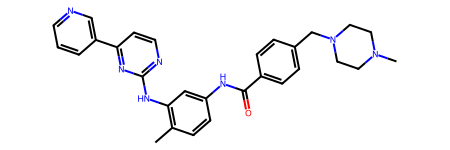

In [3]:
smis = [
    "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5",
    "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5",
    "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
]

from rdkit import Chem
from rdkit.Chem.QED import qed as rdkit_qed
mol = Chem.MolFromSmiles(smis[0])
qed_score = rdkit_qed(mol)
print(f"Original QED: {qed_score}")
mol

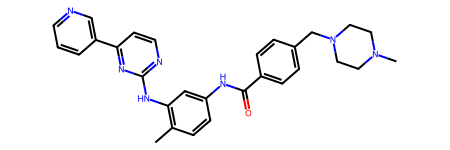

Next, we'll set up the optimizer. It takes in a client, a scoring function callback (the oracle), and the seed SMILES. The client must implement encode() and decode() methods. For this example, the molmim_cma library provides us a client which wraps the bionemo service.

In [4]:
from guided_molecule_gen.inference_client import BioNemoNIMClient

# Update IP:port below to point to your MolMIM NIM host
service_client = BioNemoNIMClient(nim_host="localhost:11393")

In [5]:
optimizer = MoleculeGenerationOptimizer(service_client, scoring_function, smis, popsize=20, optimizer_args={"sigma":1.3} )

(10_w,20)-aCMA-ES (mu_w=5.9,w_1=27%) in dimension 512 (seed=181714, Sun Nov  2 21:19:54 2025)
(10_w,20)-aCMA-ES (mu_w=5.9,w_1=27%) in dimension 512 (seed=200008, Sun Nov  2 21:19:54 2025)
(10_w,20)-aCMA-ES (mu_w=5.9,w_1=27%) in dimension 512 (seed=194660, Sun Nov  2 21:19:54 2025)


In [6]:
optimizer.original_smis

['CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5',
 'CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5',
 'CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5']

In [ ]:
composite_oracle.reset_iteration_buffer()
optimizer.step()
initial_generated_smis = optimizer.generated_smis
initial_batches = composite_oracle.pop_iteration_results()

initial_seed_metrics: List[pd.DataFrame] = []
for seed_idx, batch in enumerate(initial_batches):
    df = batch["evaluation"].assign(seed_index=seed_idx)
    initial_seed_metrics.append(df)

initial_metrics_df = pd.concat(initial_seed_metrics, ignore_index=True)
initial_metrics_df.head()

### Visualizing QED and Similarity scores after first iteration

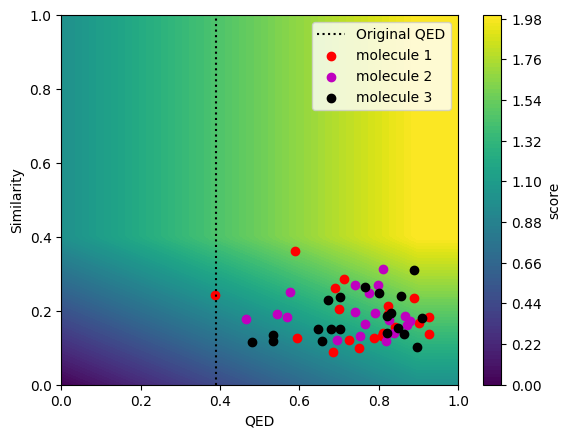

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.ion()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['r', 'm', 'k']

for seed_idx, (df, color) in enumerate(zip(initial_seed_metrics, colors)):
    axes[0].scatter(
        df["qed_score"],
        df["similarity_to_reference"],
        c=color,
        alpha=0.6,
        label=f"seed {seed_idx + 1}"
    )
axes[0].set_xlabel("QED")
axes[0].set_ylabel("Similarity to reference")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].plot([qed_score, qed_score], [0, 1], linestyle=':', c='k', label="Original QED")
axes[0].legend()

for seed_idx, (df, color) in enumerate(zip(initial_seed_metrics, colors)):
    valid = df["CDK11_ic50_nm"].notna() & (df["CDK11_ic50_nm"] > 0)
    axes[1].scatter(
        df.loc[valid, "on_target_pic50"],
        df.loc[valid, "CDK11_ic50_nm"],
        c=color,
        alpha=0.6,
    )
axes[1].set_xlabel("On-target pIC50 (CDK4/6)")
axes[1].set_ylabel("CDK11 IC50 (nM)")
axes[1].set_yscale("log")
axes[1].set_ylim(1e2, 2e4)
axes[1].axhline(1e4, color='gray', linestyle='--', linewidth=1, label="Avoidance target")
axes[1].legend(loc='lower right')

for seed_idx, (df, color) in enumerate(zip(initial_seed_metrics, colors)):
    axes[2].scatter(
        df["composite_score"],
        df["selectivity_ratio_norm"],
        c=color,
        alpha=0.6,
    )
axes[2].set_xlabel("Composite score")
axes[2].set_ylabel("Selectivity ratio (normalized)")
axes[2].set_xlim(0, 1.05)
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.draw()


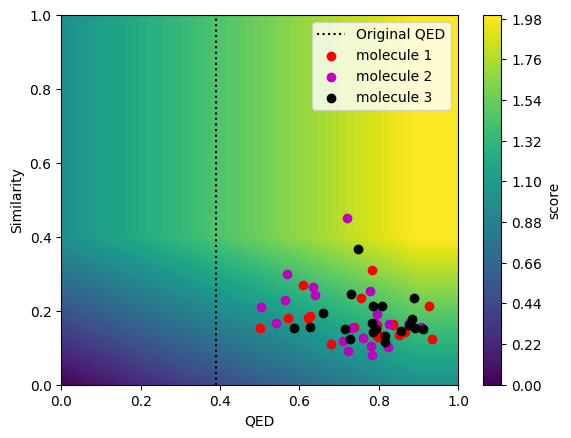

### Visualizing the molecule generation process interactively

In [ ]:
from IPython.display import display, clear_output
%matplotlib inline

n_steps = 20

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figheight(6)
fig.set_figwidth(16)

ax1.set_xlabel('QED')
ax1.set_ylabel('Similarity to reference')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
reference_line, = ax1.plot([qed_score, qed_score], [0, 1], linestyle=':', c='k', label="Original QED")
ax1.legend(loc='lower right')

metrics_history: Dict[str, List[float]] = {
    "median_composite": [],
    "median_selectivity": [],
    "median_cdk11_avoidance": [],
    "median_qed": [],
}
metrics_history["boltz2_accept_rate"] = []
scatter = None
colorbar = None

for step in range(n_steps):
    print(f"Stepping {step + 1} of {n_steps}")
    composite_oracle.reset_iteration_buffer()
    optimizer.step()
    iteration_batches = composite_oracle.pop_iteration_results()

    iteration_frames = []
    for seed_idx, batch in enumerate(iteration_batches):
        iteration_frames.append(batch["evaluation"].assign(seed_index=seed_idx))
    iteration_df = pd.concat(iteration_frames, ignore_index=True)

    metrics_history["median_composite"].append(iteration_df["composite_score"].median())
    metrics_history["median_selectivity"].append(iteration_df["selectivity_ratio_norm"].median())
    metrics_history["median_cdk11_avoidance"].append(iteration_df["cdk11_avoidance"].median())
    metrics_history["median_qed"].append(iteration_df["qed_score"].median())
    if "binding_affinity_source" in iteration_df.columns:
        accept_mask = iteration_df["binding_affinity_source"] == "boltz2"
        metrics_history["boltz2_accept_rate"].append(float(accept_mask.mean()))
    else:
        metrics_history["boltz2_accept_rate"].append(np.nan)

    points = np.column_stack(
        [iteration_df["qed_score"].to_numpy(), iteration_df["similarity_to_reference"].to_numpy()]
    )
    scores = iteration_df["composite_score"].to_numpy()

    clear_output(wait=True)
    if scatter is None:
        scatter = ax1.scatter(points[:, 0], points[:, 1], c=scores, cmap='viridis', vmin=0.0, vmax=1.0)
        colorbar = fig.colorbar(scatter, ax=ax1, label="Composite score")
    else:
        scatter.set_offsets(points)
        scatter.set_array(scores)
        scatter.set_clim(0.0, 1.0)
        if colorbar is not None:
            colorbar.update_normal(scatter)

    ax2.clear()
    ax2.plot(metrics_history["median_composite"], label='Median composite', color='purple')
    ax2.plot(metrics_history["median_selectivity"], label='Median selectivity (norm)', color='orange')
    ax2.plot(metrics_history["median_cdk11_avoidance"], label='Median CDK11 avoidance', color='green')
    ax2.plot(metrics_history["median_qed"], label='Median QED', color='blue')
    if USE_BOLTZ2:
        ax2.plot(metrics_history["boltz2_accept_rate"], label='Boltz2 acceptance', color='black', linestyle='--')
    ax2.axhline(0.85, linestyle='--', color='gray', linewidth=1, label='Composite 0.85')
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Value")
    ax2.set_xlim(0, n_steps)
    ax2.set_ylim(0, 1.05)
    ax2.legend(loc='lower right')

    display(fig)


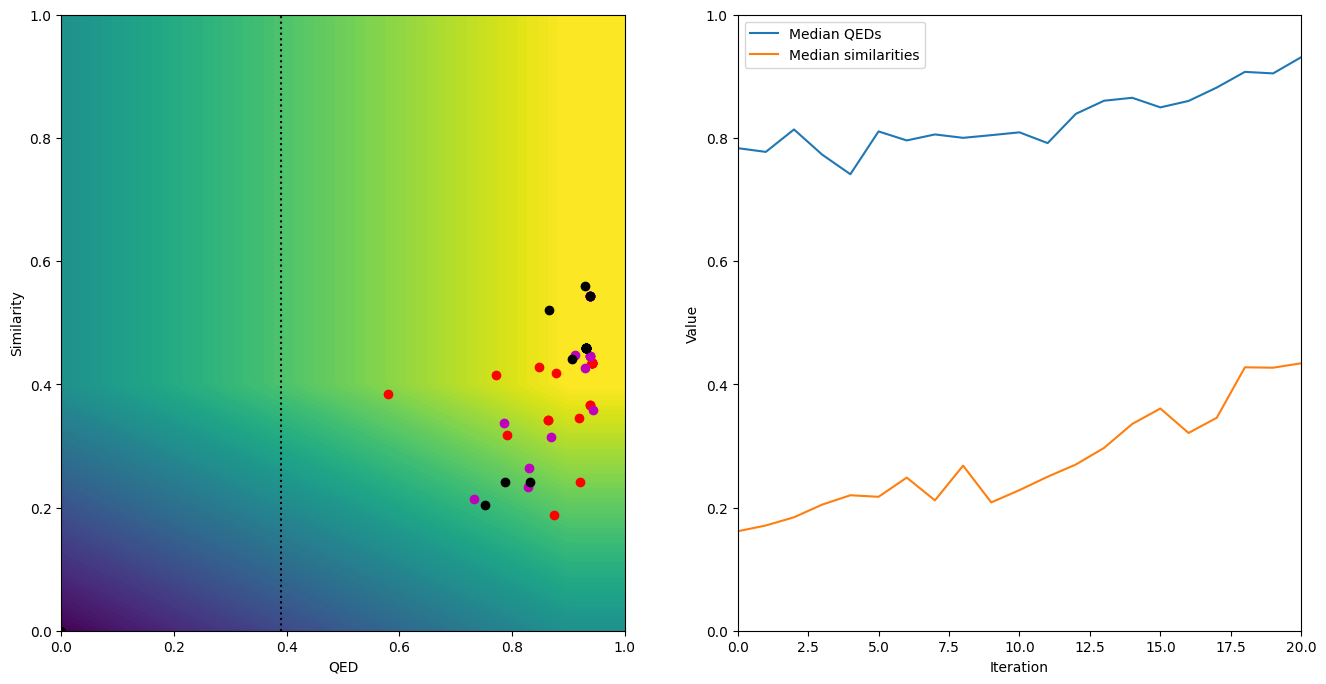

### Exploring Alternative Weightings

We can bias the composite score toward novelty-heavy exploration while still reusing the evaluator-aligned components. Below we clone the oracle with tweaked weights to encourage higher novelty and synthetic accessibility.

In [ ]:
novelty_leaning_weights = EVALUATION_WEIGHTS.copy()
novelty_leaning_weights.update({
    "binding_affinity": 0.20,
    "novelty": 0.15,
    "sa": 0.15,
})

novelty_oracle = CompositeScoreOracle(
    weights=novelty_leaning_weights,
    novelty_cutoff=NOVELTY_CUTOFF,
    chembl_data_path=chembl_data_dir,
    use_boltz2=USE_BOLTZ2,
    boltz2_url=BOLTZ2_URL,
    boltz2_api_key=BOLTZ2_API_KEY,
    boltz2_confidence_threshold=BOLTZ2_CONFIDENCE_THRESHOLD,
)


def novelty_scoring_function(smiles: List[str], **kwargs) -> np.ndarray:
    return novelty_oracle(smiles, **kwargs)


In [ ]:
weight_comparison = pd.DataFrame({
    "baseline": pd.Series(EVALUATION_WEIGHTS),
    "novelty_leaning": pd.Series(novelty_leaning_weights),
}).reindex(EVALUATION_WEIGHTS.keys())
weight_comparison

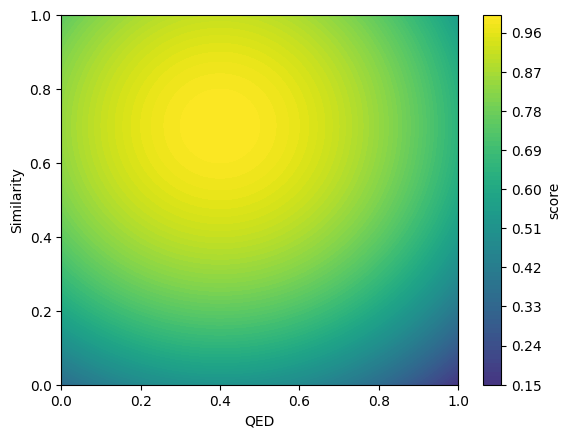

In [ ]:
optimizer = MoleculeGenerationOptimizer(service_client, novelty_scoring_function, smis, popsize=20)

(10_w,20)-aCMA-ES (mu_w=5.9,w_1=27%) in dimension 512 (seed=234845, Sun Nov  2 21:21:20 2025)
(10_w,20)-aCMA-ES (mu_w=5.9,w_1=27%) in dimension 512 (seed=179377, Sun Nov  2 21:21:20 2025)
(10_w,20)-aCMA-ES (mu_w=5.9,w_1=27%) in dimension 512 (seed=249181, Sun Nov  2 21:21:20 2025)


In [ ]:
from IPython.display import display, clear_output
%matplotlib inline

n_steps = 30

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figheight(6)
fig.set_figwidth(16)

ax1.set_xlabel('Novelty score')
ax1.set_ylabel('QED')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axvline(1 - NOVELTY_CUTOFF, linestyle='--', color='gray', linewidth=1, label='Novelty cutoff proxy')
ax1.legend(loc='lower right')

novelty_history: Dict[str, List[float]] = {
    "median_composite": [],
    "median_novelty": [],
    "median_sa": [],
    "median_qed": [],
    "boltz2_accept_rate": [],
}
novelty_scatter = None
novelty_cbar = None

for step in range(n_steps):
    print(f"Stepping {step + 1} of {n_steps}")
    novelty_oracle.reset_iteration_buffer()
    optimizer.step()
    iteration_batches = novelty_oracle.pop_iteration_results()

    frames = []
    for seed_idx, batch in enumerate(iteration_batches):
        frames.append(batch["evaluation"].assign(seed_index=seed_idx))
    iteration_df = pd.concat(frames, ignore_index=True)

    novelty_history["median_composite"].append(iteration_df["composite_score"].median())
    novelty_history["median_novelty"].append(iteration_df["novelty_score"].median())
    novelty_history["median_sa"].append(iteration_df["sa_score_normalized"].median())
    novelty_history["median_qed"].append(iteration_df["qed_score"].median())
    if "binding_affinity_source" in iteration_df.columns:
        accept_mask = iteration_df["binding_affinity_source"] == "boltz2"
        novelty_history["boltz2_accept_rate"].append(float(accept_mask.mean()))
    else:
        novelty_history["boltz2_accept_rate"].append(np.nan)

    points = np.column_stack([
        iteration_df["novelty_score"].to_numpy(),
        iteration_df["qed_score"].to_numpy(),
    ])
    scores = iteration_df["composite_score"].to_numpy()

    clear_output(wait=True)
    if novelty_scatter is None:
        novelty_scatter = ax1.scatter(points[:, 0], points[:, 1], c=scores, cmap='plasma', vmin=0.0, vmax=1.0)
        novelty_cbar = fig.colorbar(novelty_scatter, ax=ax1, label="Composite score")
    else:
        novelty_scatter.set_offsets(points)
        novelty_scatter.set_array(scores)
        novelty_scatter.set_clim(0.0, 1.0)
        if novelty_cbar is not None:
            novelty_cbar.update_normal(novelty_scatter)

    ax2.clear()
    ax2.plot(novelty_history["median_composite"], label='Median composite', color='purple')
    ax2.plot(novelty_history["median_novelty"], label='Median novelty', color='teal')
    ax2.plot(novelty_history["median_sa"], label='Median SA (norm)', color='orange')
    ax2.plot(novelty_history["median_qed"], label='Median QED', color='blue')
    if USE_BOLTZ2:
        ax2.plot(novelty_history["boltz2_accept_rate"], label='Boltz2 acceptance', color='black', linestyle='--')
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Value")
    ax2.set_xlim(0, n_steps)
    ax2.set_ylim(0, 1.05)
    ax2.legend(loc='lower right')

    display(fig)

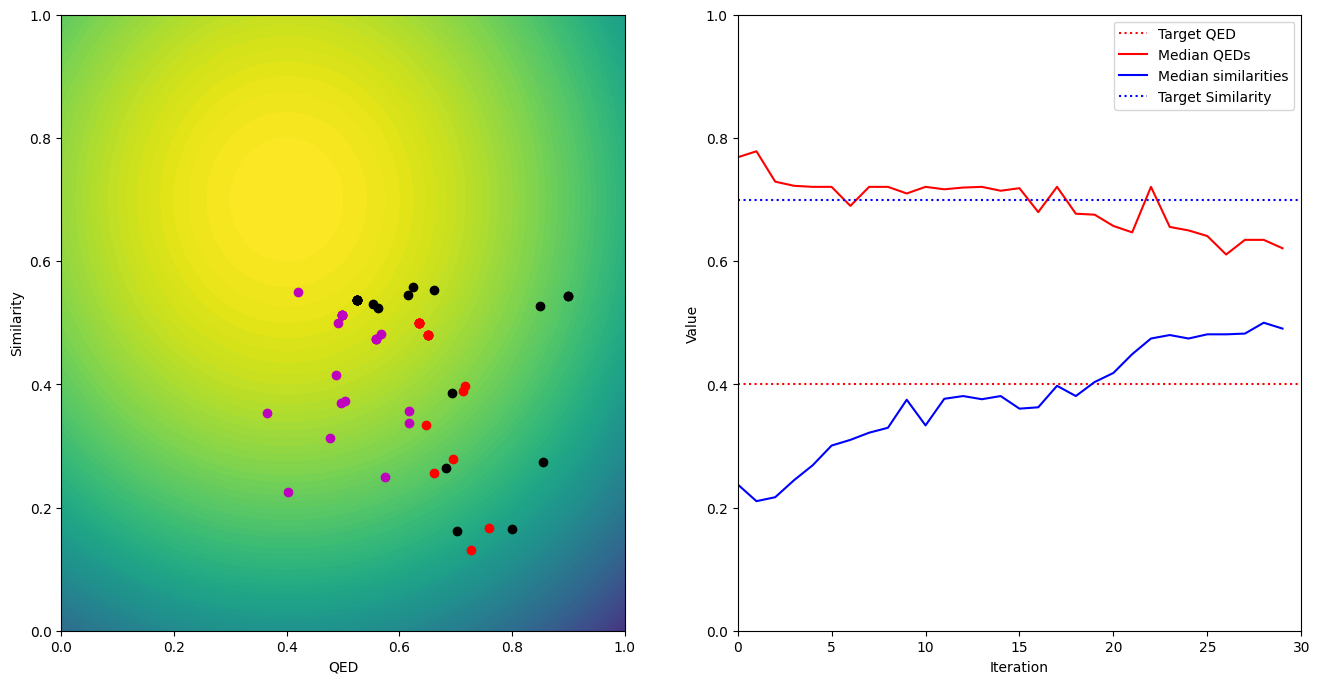

# Licensing

Copyright © 2025 OpenACC-Standard.org.  This material is released by OpenACC-Standard.org, in collaboration with NVIDIA Corporation, under the Creative Commons Attribution 4.0 International (CC BY 4.0). These materials may include references to hardware and software developed by other entities; all applicable licensing and copyrights apply.